In [2]:
import json
import ssl
import urllib.parse
import urllib.request

import certifi

params = urllib.parse.urlencode(
    {
        "start": "1",
        "limit": "10",
        "convert": "USD",
    }
)

request = urllib.request.Request(
    f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
    headers={
        "Accept": "application/json",
        "X-CMC_PRO_API_KEY": "e97bc1bbe52a48c39518935ac9c1dc82",
    },
)

context = ssl.create_default_context(cafile=certifi.where())

with urllib.request.urlopen(request, context=context) as response:
    data = json.load(response)

print(data)

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20086834, 'total_supply': 20086834, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12751, 'cmc_rank': 1, 'last_updated': '2026-09-20T05:10:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1616612383244.28, 'quote': {'USD': {'price': 80481.19396238748, 'volume_24h': 21920200984.508213, 'cex_volume_24h': 21882072895.979675, 'dex_volume_24h': 38128088.52853739, 'volume_change_24h': -43.6784, 'percent_change_1h': 0.07512036, 'percent_change_24h': -0.75589462, 'percent_change_7d': 4.23712799, 'percent_change_30d': 7.0290855, 'percent_change_60d': 21.51451295, 'percent_change_90d': 25.42782394, 'market_cap': 1616612383244.2795, 'market_cap_dominance': 58.8597, 'fully_diluted_market_cap': 1690105073210.14, 'tvl': None, 'last_updated': '2026

In [3]:
type(data)

dict

In [4]:
import pandas as pd

#This allows you to see the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
#This normalizes th data and makes it all pretty in a dataframe

df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.008683e+07,2.008683e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12751,1,2026-09-20T05:10:00.000Z,None,NaN,NaN,NaN,1.616612e+12,"[mineable, pow, sha-256, store-of-value, state...",80481.193962,2.192020e+10,2.188207e+10,3.812809e+07,-43.6784,0.075120,-0.755895,4.237128,7.029085,21.514513,25.427824,1.616612e+12,58.8597,1.690105e+12,None,2026-09-20T05:10:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:46.819418
1,1027,Ethereum,ETH,ethereum,True,1.220647e+08,1.220647e+08,NaN,2015-08-07T00:00:00.000Z,13614,2,2026-09-20T05:11:00.000Z,None,NaN,NaN,NaN,3.148504e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2579.371978,1.037782e+10,1.019825e+10,1.795665e+08,-51.6659,-0.179347,-1.778260,2.340268,9.483258,33.501755,48.604363,3.148504e+11,11.4635,3.148504e+11,None,2026-09-20T05:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:46.819418
2,825,Tether USDt,USDT,tether,True,1.833846e+11,1.893274e+11,NaN,2015-02-25T00:00:00.000Z,201233,3,2026-09-20T05:10:00.000Z,None,NaN,NaN,NaN,1.892621e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999655,6.105604e+10,5.980531e+10,1.250730e+09,-35.3284,0.004659,0.003974,0.002808,0.004378,0.042216,0.088837,1.833213e+11,6.6746,1.892621e+11,None,2026-09-20T05:10:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-09-20 12:12:46.819418
3,1839,BNB,BNB,bnb,False,1.331603e+08,1.331603e+08,1.331603e+08,2017-07-25T00:00:00.000Z,3469,4,2026-09-20T05:10:00.000Z,None,NaN,NaN,NaN,9.976683e+10,"[marketplace, centralized-exchange, payments, ...",749.223568,1.532250e+09,1.506927e+09,2.532298e+07,-26.1052,-0.002343,-1.609089,3.150408,13.310395,31.136736,26.986188,9.976683e+10,3.6324,9.976683e+10,None,2026-09-20T05:10:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:46.819418
4,52,XRP,XRP,xrp,False,6.287921e+10,9.998562e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1885,5,2026-09-20T05:11:00.000Z,None,NaN,NaN,NaN,1.381753e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.381952,3.574299e+09,3.570785e+09,3.514984e+06,-26.8096,0.002317,-2.573253,1.259429,5.423053,21.154392,21.775363,8.689605e+10,3.1638,1.381952e+11,None,2026-09-20T05:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:46.819418
5,3408,USDC,USDC,usd-coin,False,7.423698e+10,7.423698e+10,NaN,2018-10-08T00:00:00.000Z,45429,6,2026-09-20T05:10:00.000Z,None,NaN,6.090122e+10,6.089497e+10,7.422937e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999897,1.004665e+10,8.610698e+09,1.435950e+09,-42.0003,0.000729,0.015057,0.013774,0.010295,0.005816,0.013625,7.422937e+10,2.7026,7.422937e+10,None,2026-09-20T05:10:00.000Z,24091.0,zksync,zkSync Era,ZK,0x1d17CBcF0D6D143135aE902365D2E5e2A16538D4,2026-09-20 12:12:46.819418
6,5426,Solana,SOL,solana,True,5.873671e+08,6.343758e+08,NaN,2020-04-10T00:00:00.000Z,1179,7,2026-09-20T05:11:00.000Z,None,NaN,5.252369e+08,5.724845e+10,6.914410e+10,"[pos, platform, solana-ecosystem, cms-holdings...",108.995491,3.053668e+09,3.053627e+09,4.060802e+04,-48.5029,0.172533,-3.215101,7.100955,21.861403,39.948053,47.349401,6.402037e+10,2.3309,6.914410e+10,None,2026-09-20T05:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:46.819418
7,1958,TRON,TRX,tron,True,9.495821e+10,9.495821e+10,NaN,2017-09-13T00:00:00.000Z,1379,8,2026-09-20T05:11:00.000Z,None,NaN,9.466

In [6]:
def api_runner():
    global df
    params = urllib.parse.urlencode(
        {
            "start": "1",
            "limit": "10",
            "convert": "USD",
        }
    )
    
    request = urllib.request.Request(
        f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
        headers={
            "Accept": "application/json",
            "X-CMC_PRO_API_KEY": "e97bc1bbe52a48c39518935ac9c1dc82",
        },
    )
    
    context = ssl.create_default_context(cafile=certifi.where())
    
    with urllib.request.urlopen(request, context=context) as response:
        data = json.load(response)
    
    print(data)

#Note:
#I had to go in and put 'jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10'
#Into the Anaconda Prompt ro change this to allow to pull data

    df = pd.json_normalize(data['data'])
    df['timestamp'] = pd.to_datetime('now')
    df 

    if not os.path.isfile(r'E:\Python project\API.CSV'):
        df.to_csv(r'E:\Python project\API.CSV', header = 'column_names')
    else:
        df.to_csv(r'E:\Python project\API.CSV', mode = 'a', header = False)
#If that didn't work try using the local host URL as shown in the video

In [7]:
import os
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner completed')
    sleep(60) #sleep for 1 minute
    exit()

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20086834, 'total_supply': 20086834, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12751, 'cmc_rank': 1, 'last_updated': '2026-09-20T05:11:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1616932845959.51, 'quote': {'USD': {'price': 80497.1478312367, 'volume_24h': 21919780073.101097, 'cex_volume_24h': 21881651912.959297, 'dex_volume_24h': 38128160.14179854, 'volume_change_24h': -43.6894, 'percent_change_1h': 0.12280545, 'percent_change_24h': -0.70227252, 'percent_change_7d': 4.25166734, 'percent_change_30d': 7.01466982, 'percent_change_60d': 21.51002361, 'percent_change_90d': 25.41213657, 'market_cap': 1616932845959.5117, 'market_cap_dominance': 58.8713, 'fully_diluted_market_cap': 1690440104455.97, 'tvl': None, 'last_updated': '2026

KeyboardInterrupt: 

In [8]:
df72 = pd.read_csv(r'E:\Python project\API.CSV')
df72

,Unnamed: 0,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,0,1,Bitcoin,BTC,bitcoin,False,2.008681e+07,2.008681e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12751,1,2026-09-20T03:49:00.000Z,NaN,NaN,NaN,NaN,1.615157e+12,"['mineable', 'pow', 'sha-256', 'store-of-value...",80408.869118,2.162496e+10,2.158693e+10,3.802268e+07,-45.8693,-0.206158,-0.920967,4.184292,7.595241,21.274225,25.423222,1.615157e+12,58.9133,1.688586e+12,NaN,2026-09-20T03:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 10:51:07.552004
1,1,1027,Ethereum,ETH,ethereum,True,1.220647e+08,1.220647e+08,NaN,2015-08-07T00:00:00.000Z,13613,2,2026-09-20T03:49:00.000Z,NaN,NaN,NaN,NaN,3.153180e+11,"['pos', 'smart-contracts', 'ethereum-ecosystem...",2583.202638,1.033401e+10,1.014620e+10,1.878036e+08,-53.5416,-0.361254,-1.453776,2.505419,9.860376,33.591247,49.127158,3.153180e+11,11.5013,3.153180e+11,NaN,2026-09-20T03:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 10:51:07.552004
2,2,825,Tether USDt,USDT,tether,True,1.833846e+11,1.893274e+11,NaN,2015-02-25T00:00:00.000Z,201226,3,2026-09-20T03:49:00.000Z,NaN,NaN,NaN,NaN,1.892537e+11,"['stablecoin', 'asset-backed-stablecoin', 'usd...",0.999611,6.114833e+10,5.987047e+10,1.277858e+09,-36.9537,-0.000905,-0.004040,-0.012777,0.012830,0.041186,0.079328,1.833133e+11,6.6864,1.892537e+11,NaN,2026-09-20T03:49:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-09-20 10:51:07.552004
3,3,1839,BNB,BNB,bnb,False,1.331603e+08,1.331603e+08,1.331603e+08,2017-07-25T00:00:00.000Z,3469,4,2026-09-20T03:49:00.000Z,NaN,NaN,NaN,NaN,9.962543e+10,"['marketplace', 'centralized-exchange', 'payme...",748.161681,1.564037e+09,1.538703e+09,2.533328e+07,-24.4933,-0.850252,-1.521648,2.873926,13.130056,30.844304,26.703170,9.962543e+10,3.6339,9.962543e+10,NaN,2026-09-20T03:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 10:51:07.552004
4,4,52,XRP,XRP,xrp,False,6.287921e+10,9.998562e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1885,5,2026-09-20T03:50:00.000Z,NaN,NaN,NaN,NaN,1.378981e+11,"['medium-of-exchange', 'enterprise-solutions',...",1.379179,3.654781e+09,3.651141e+09,3.640120e+06,-26.0607,-0.168800,-2.469538,1.169972,5.102901,20.943488,21.865544,8.672172e+10,3.1632,1.379179e+11,NaN,2026-09-20T03:50:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 10:51:07.552004
5,5,3408,USDC,USDC,usd-coin,False,7.424729e+10,7.424729e+10,NaN,2018-10-08T00:00:00.000Z,45427,6,2026-09-20T03:49:00.000Z,NaN,NaN,6.090122e+10,6.089480e+10,7.423946e+10,"['medium-of-exchange', 'stablecoin', 'asset-ba...",0.999895,1.008999e+10,8.628050e+09,1.461938e+09,-43.0024,0.010268,0.008985,0.012598,0.005897,0.007250,0.015569,7.423946e+10,2.7079,7.423946e+10,NaN,2026-09-20T03:49:00.000Z,24091.0,zksync,zkSync Era,ZK,0x1d17CBcF0D6D143135aE902365D2E5e2A16538D4,2026-09-20 10:51:07.552004
6,6,5426,Solana,SOL,solana,True,5.873672e+08,6.343759e+08,NaN,2020-04-10T00:00:00.000Z,1179,7,2026-09-20T03:50:00.000Z,NaN,NaN,5.252369e+08,5.704199e+10,6.889475e+10,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",108.602413,3.108850e+09,3.108807e+09,4.337195e+04,-50.5941,0.166484,-4.200448,6.782431,21.518918,39.123291,47.633250,6.378949e+10,2.3267,6.889475e+10,NaN,2026-09-20T03:50:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 10:51:07.552004
7,7,1958,TRON,TRX,tron,True,9.495810e+10,9.495808e+10,NaN,2017-09-13T00:00:00.000Z,1379,8,2026-09-20T03:50:00.0

In [9]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.008683e+07,2.008683e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12751,1,2026-09-20T05:11:00.000Z,None,NaN,NaN,NaN,1.616933e+12,"[mineable, pow, sha-256, store-of-value, state...",80497.147831,2.191978e+10,2.188165e+10,3.812816e+07,-43.6894,0.122805,-0.702273,4.251667,7.014670,21.510024,25.412137,1.616933e+12,58.8713,1.690440e+12,None,2026-09-20T05:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:55.331136
1,1027,Ethereum,ETH,ethereum,True,1.220647e+08,1.220647e+08,NaN,2015-08-07T00:00:00.000Z,13614,2,2026-09-20T05:11:00.000Z,None,NaN,NaN,NaN,3.148504e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2579.371978,1.037782e+10,1.019825e+10,1.795665e+08,-51.6659,-0.179347,-1.778260,2.340268,9.483258,33.501755,48.604363,3.148504e+11,11.4635,3.148504e+11,None,2026-09-20T05:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:55.331136
2,825,Tether USDt,USDT,tether,True,1.833846e+11,1.893274e+11,NaN,2015-02-25T00:00:00.000Z,201234,3,2026-09-20T05:11:00.000Z,None,NaN,NaN,NaN,1.892610e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999649,6.105115e+10,5.980356e+10,1.247585e+09,-35.3370,0.004677,-0.000900,-0.006631,0.001755,0.032361,0.084157,1.833203e+11,6.6746,1.892610e+11,None,2026-09-20T05:11:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-09-20 12:12:55.331136
3,1839,BNB,BNB,bnb,False,1.331603e+08,1.331603e+08,1.331603e+08,2017-07-25T00:00:00.000Z,3469,4,2026-09-20T05:11:00.000Z,None,NaN,NaN,NaN,9.977307e+10,"[marketplace, centralized-exchange, payments, ...",749.270474,1.532282e+09,1.506964e+09,2.531860e+07,-26.0972,0.010524,-1.603045,3.153389,13.318477,31.139482,26.980085,9.977307e+10,3.6327,9.977307e+10,None,2026-09-20T05:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:55.331136
4,52,XRP,XRP,xrp,False,6.287921e+10,9.998562e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1885,5,2026-09-20T05:12:00.000Z,None,NaN,NaN,NaN,1.382105e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.382304,3.573848e+09,3.570334e+09,3.514751e+06,-26.8234,0.030455,-2.574729,1.266205,5.411366,21.268923,21.736194,8.691818e+10,3.1646,1.382304e+11,None,2026-09-20T05:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:55.331136
5,3408,USDC,USDC,usd-coin,False,7.423698e+10,7.423698e+10,NaN,2018-10-08T00:00:00.000Z,45429,6,2026-09-20T05:11:00.000Z,None,NaN,6.090122e+10,6.089567e+10,7.423022e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999909,1.004067e+10,8.604977e+09,1.435691e+09,-42.0345,0.007520,-0.001030,0.010812,-0.010797,-0.010199,0.010815,7.423022e+10,2.7027,7.423022e+10,None,2026-09-20T05:11:00.000Z,24091.0,zksync,zkSync Era,ZK,0x1d17CBcF0D6D143135aE902365D2E5e2A16538D4,2026-09-20 12:12:55.331136
6,5426,Solana,SOL,solana,True,5.873671e+08,6.343758e+08,NaN,2020-04-10T00:00:00.000Z,1179,7,2026-09-20T05:12:00.000Z,None,NaN,5.252369e+08,5.725723e+10,6.915470e+10,"[pos, platform, solana-ecosystem, cms-holdings...",109.012196,3.053783e+09,3.053742e+09,4.060798e+04,-48.4819,0.205399,-3.197306,7.087922,21.820073,40.043169,47.329457,6.403018e+10,2.3313,6.915470e+10,None,2026-09-20T05:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:55.331136
7,1958,TRON,TRX,tron,True,9.495821e+10,9.495821e+10,NaN,2017-09-13T00:00:00.000Z,1379,8,2026-09-20T05:12:00.000Z,None,NaN,9

In [11]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [16]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20086834.00000,20086834.00000,21000000.00000,2010-07-13T00:00:00.000Z,12751,1,2026-09-20T05:11:00.000Z,None,NaN,NaN,NaN,1616932845959.51001,"[mineable, pow, sha-256, store-of-value, state...",80497.14783,21919780073.10110,21881651912.95930,38128160.14180,-43.68940,0.12281,-0.70227,4.25167,7.01467,21.51002,25.41214,1616932845959.51172,58.87130,1690440104455.96997,None,2026-09-20T05:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:55.331136
1,1027,Ethereum,ETH,ethereum,True,122064744.06907,122064744.06907,NaN,2015-08-07T00:00:00.000Z,13614,2,2026-09-20T05:11:00.000Z,None,NaN,NaN,NaN,314850380313.16998,"[pos, smart-contracts, ethereum-ecosystem, coi...",2579.37198,10377815369.37454,10198248912.67870,179566456.69585,-51.66590,-0.17935,-1.77826,2.34027,9.48326,33.50175,48.60436,314850380313.17035,11.46350,314850380313.16998,None,2026-09-20T05:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:55.331136
2,825,Tether USDt,USDT,tether,True,183384649789.28110,189327421045.46777,NaN,2015-02-25T00:00:00.000Z,201234,3,2026-09-20T05:11:00.000Z,None,NaN,NaN,NaN,189260993084.26999,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99965,61051145673.81522,59803560767.63296,1247584906.18223,-35.33700,0.00468,-0.00090,-0.00663,0.00175,0.03236,0.08416,183320306925.82266,6.67460,189260993084.26999,None,2026-09-20T05:11:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-09-20 12:12:55.331136
3,1839,BNB,BNB,bnb,False,133160289.53000,133160289.53000,133160289.53000,2017-07-25T00:00:00.000Z,3469,4,2026-09-20T05:11:00.000Z,None,NaN,NaN,NaN,99773073207.46001,"[marketplace, centralized-exchange, payments, ...",749.27047,1532282126.15541,1506963525.22203,25318600.93338,-26.09720,0.01052,-1.60305,3.15339,13.31848,31.13948,26.98008,99773073207.45557,3.63270,99773073207.46001,None,2026-09-20T05:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:55.331136
4,52,XRP,XRP,xrp,False,62879209849.00000,99985622230.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1885,5,2026-09-20T05:12:00.000Z,None,NaN,NaN,NaN,138210512768.37000,"[medium-of-exchange, enterprise-solutions, xrp...",1.38230,3573848320.13937,3570333569.40745,3514750.73192,-26.82340,0.03046,-2.57473,1.26621,5.41137,21.26892,21.73619,86918175252.32880,3.16460,138230387215.51001,None,2026-09-20T05:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-09-20 12:12:55.331136
5,3408,USDC,USDC,usd-coin,False,74236984782.14287,74236984782.14287,NaN,2018-10-08T00:00:00.000Z,45429,6,2026-09-20T05:11:00.000Z,None,NaN,60901219650.23000,60895671491.04529,74230221722.03999,"[medium-of-exchange, stablecoin, asset-backed-...",0.99991,10040668106.24724,8604977071.73280,1435691034.51443,-42.03450,0.00752,-0.00103,0.01081,-0.01080,-0.01020,0.01081,74230221722.03783,2.70270,74230221722.03999,None,2026-09-20T05:11:00.000Z,24091.00000,zksync,zkSync Era,ZK,0x1d17CBcF0D6D143135aE902365D2E5e2A16538D4,2026-09-20 12:12:55.331136
6,5426,Solana,SOL,solana,True,587367120.52611,634375799.70418,NaN,2020-04-10T00:00:00.000Z,1179,7,2026-09-20T05:12:00.000Z,None,NaN,525236893.30000,57257227254.56291,69154699130.61000,"[pos, platform, solana-ecosystem, cms-holdings...",109.01220,3053782651.26696,3053742043.28361,40607.98336,-48.48190,0.20540,-3.19731,7.08792,21.82007,40.04317,

In [19]:
df3 = df.groupby('name', sort= False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.12281,-0.70227,4.25167,7.01467,21.51002,25.41214
Ethereum,-0.17935,-1.77826,2.34027,9.48326,33.50175,48.60436
Tether USDt,0.00468,-0.00090,-0.00663,0.00175,0.03236,0.08416
BNB,0.01052,-1.60305,3.15339,13.31848,31.13948,26.98008
XRP,0.03046,-2.57473,1.26621,5.41137,21.26892,21.73619
USDC,0.00752,-0.00103,0.01081,-0.01080,-0.01020,0.01081
Solana,0.20540,-3.19731,7.08792,21.82007,40.04317,47.32946
TRON,0.00632,0.49729,0.16800,0.65411,3.35741,3.65743
Zcash,0.29014,-4.92078,27.08444,143.86718,178.90905,228.15552


In [20]:
df4 = df3.stack()
df4

name                                     
Bitcoin      quote.USD.percent_change_1h      0.12281
             quote.USD.percent_change_24h    -0.70227
             quote.USD.percent_change_7d      4.25167
             quote.USD.percent_change_30d     7.01467
             quote.USD.percent_change_60d    21.51002
             quote.USD.percent_change_90d    25.41214
Ethereum     quote.USD.percent_change_1h     -0.17935
             quote.USD.percent_change_24h    -1.77826
             quote.USD.percent_change_7d      2.34027
             quote.USD.percent_change_30d     9.48326
             quote.USD.percent_change_60d    33.50175
             quote.USD.percent_change_90d    48.60436
Tether USDt  quote.USD.percent_change_1h      0.00468
             quote.USD.percent_change_24h    -0.00090
             quote.USD.percent_change_7d     -0.00663
             quote.USD.percent_change_30d     0.00175
             quote.USD.percent_change_60d     0.03236
             quote.USD.percent_change_90

In [22]:
type(df4)

pandas.Series

In [23]:
df5 = df4.to_frame(name='values')
df5

values
name                                              
Bitcoin     quote.USD.percent_change_1h    0.12281
            quote.USD.percent_change_24h  -0.70227
            quote.USD.percent_change_7d    4.25167
            quote.USD.percent_change_30d   7.01467
            quote.USD.percent_change_60d  21.51002
            quote.USD.percent_change_90d  25.41214
Ethereum    quote.USD.percent_change_1h   -0.17935
            quote.USD.percent_change_24h  -1.77826
            quote.USD.percent_change_7d    2.34027
            quote.USD.percent_change_30d   9.48326
            quote.USD.percent_change_60d  33.50175
            quote.USD.percent_change_90d  48.60436
Tether USDt quote.USD.percent_change_1h    0.00468
            quote.USD.percent_change_24h  -0.00090
            quote.USD.percent_change_7d   -0.00663
            quote.USD.percent_change_30d   0.00175
            quote.USD.percent_change_60d   0.03236
            quote.USD.percent_change_90d   0.08416
BNB         quote.USD.percent_change_1h    0.01052
            quote.USD.percent_change_24h  -1.60305
            quote.USD.percent_change_7d    3.15339
            quote.USD.percent_change_30d  13.31848
            quote.USD.percent_change_60d  31.13948
            quote.USD.percent_change_90d  26.98008
XRP         quote.USD.percent_change_1h    0.03046
            quote.USD.percent_change_24h  -2.57473
            quote.USD.percent_change_7d    1.26621
            quote.USD.percent_change_30d   5.41137
            quote.USD.percent_change_60d  21.26892
            quote.USD.percent_change_90d  21.73619
USDC        quote.USD.percent_change_1h    0.00752
            quote.USD.percent_change_24h  -0.00103
            quote.USD.percent_change_7d    0.01081
            quote.USD.percent_change_30d  -0.01080
            quote.USD.percent_change_60d  -0.01020
            quote.USD.percent_change_90d   0.01081
Solana      quote.USD.percent_change_1h    0.20540
            quote.USD.percent_change_24h  -3.19731
            quote.USD.percent_change_7d    7.08792
            quote.USD.percent_change_30d  21.82007
            quote.USD.percent_change_60d  40.04317
            quote.USD.percent_change_90d  47.32946
TRON        quote.USD.percent_change_1h    0.00632
            quote.USD.percent_change_24h   0.49729
            quote.USD.percent_change_7d    0.16800
            quote.USD.percent_change_30d   0.65411
            quote.USD.percent_change_60d   3.35741
            quote.USD.percent_change_90d   3.65743
Zcash       quote.USD.percent_change_1h    0.29014
            quote.USD.percent_change_24h  -4.92078
            quote.USD.percent_change_7d   27.08444
            quote.USD.percent_change_30d 143.86718
            quote.USD.percent_change_60d 178.90905
            quote.USD.percent_change_90d 228.15552
Hyperliquid quote.USD.percent_change_1h    0.22974
            quote.USD.percent_change_24h  -1.84831
            quote.USD.percent_change_7d   14.81010
            quote.USD.percent_change_30d  25.36321
            quote.USD.percent_change_60d  51.56894
            quote.USD.percent_change_90d  37.73577

In [29]:
df5.count()

values    60
dtype: int64

In [34]:
index = pd.Index(range(60))

df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,0.12281
1,Bitcoin,quote.USD.percent_change_24h,-0.70227
2,Bitcoin,quote.USD.percent_change_7d,4.25167
3,Bitcoin,quote.USD.percent_change_30d,7.01467
4,Bitcoin,quote.USD.percent_change_60d,21.51002
5,Bitcoin,quote.USD.percent_change_90d,25.41214
6,Ethereum,quote.USD.percent_change_1h,-0.17935
7,Ethereum,quote.USD.percent_change_24h,-1.77826
8,Ethereum,quote.USD.percent_change_7d,2.34027
9,Ethereum,quote.USD.percent_change_30d,9.48326


In [35]:
df7 = df6.rename(columns={'level_1': 'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,0.12281
1,Bitcoin,quote.USD.percent_change_24h,-0.70227
2,Bitcoin,quote.USD.percent_change_7d,4.25167
3,Bitcoin,quote.USD.percent_change_30d,7.01467
4,Bitcoin,quote.USD.percent_change_60d,21.51002
5,Bitcoin,quote.USD.percent_change_90d,25.41214
6,Ethereum,quote.USD.percent_change_1h,-0.17935
7,Ethereum,quote.USD.percent_change_24h,-1.77826
8,Ethereum,quote.USD.percent_change_7d,2.34027
9,Ethereum,quote.USD.percent_change_30d,9.48326


In [46]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,1h,0.12281
1,Bitcoin,24h,-0.70227
2,Bitcoin,7d,4.25167
3,Bitcoin,30d,7.01467
4,Bitcoin,60d,21.51002
5,Bitcoin,90d,25.41214
6,Ethereum,1h,-0.17935
7,Ethereum,24h,-1.77826
8,Ethereum,7d,2.34027
9,Ethereum,30d,9.48326


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

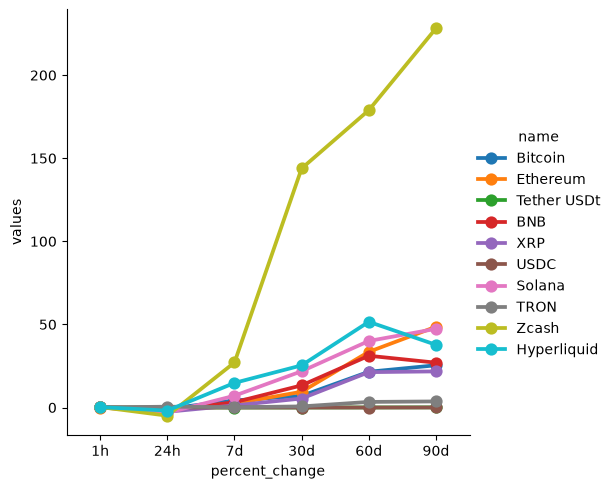

In [47]:
sns.catplot(x='percent_change', y='values', hue = 'name', data = df7, kind = 'point')

In [55]:
df10 = df[['name','quote.USD.price','timestamp']]
df10 = df10.query("name == 'Hyperliquid'")
df10

,name,quote.USD.price,timestamp
9,Hyperliquid,90.98777,2026-09-20 12:12:55.331136


In [62]:
!pip install requests pandas

In [63]:
import pandas as pd
import requests

# Endpoint API CoinGecko untuk riwayat harga Hyperliquid
url = 'https://api.coingecko.com/api/v3/coins/hyperliquid/market_chart?vs_currency=usd&days=30'
response = requests.get(url)
data = response.json()

# Olah data harga ke DataFrame
df_history = pd.DataFrame(data['prices'], columns=['timestamp', 'price'])
df_history['Date'] = pd.to_datetime(df_history['timestamp'], unit='ms')

# Tampilkan data
df_history[['Date', 'price']]

,Date,price
0,2026-08-21 07:00:00,72.82515
1,2026-08-21 08:00:00,73.74450
2,2026-08-21 09:00:00,75.72367
3,2026-08-21 10:00:00,74.06595
4,2026-08-21 11:00:00,74.95554
5,2026-08-21 12:00:00,74.15345
6,2026-08-21 13:00:00,74.11609
7,2026-08-21 14:00:00,76.94691
8,2026-08-21 15:00:00,77.42380
9,2026-08-21 16:00:00,76.56016


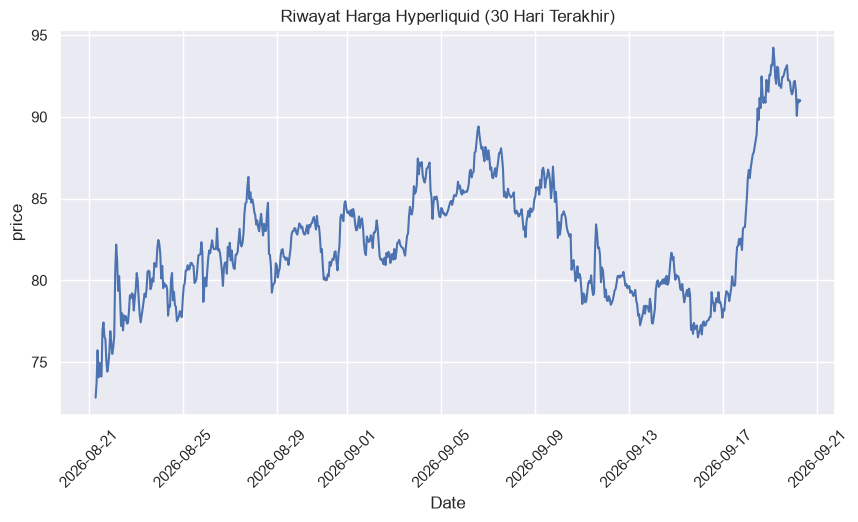

In [65]:
sns.set_theme(style='darkgrid')

plt.figure(figsize=(10, 5))
sns.lineplot(x='Date', y='price', data=df_history)
plt.title('Riwayat Harga Hyperliquid (30 Hari Terakhir)')
plt.xticks(rotation=45)
plt.show()